# Plotly maps
- Various map types and overlays are available.
- Open Street Map is open for use without a token.
- Overlays include scatter, lines, densities, etc.
- Choropleths (coloured map sections) can be used as overlays or as separate plots when a GeoJSON formated dictionary of map polygons are available.

## Mapbox
- The mapbox allows for user defined overlays

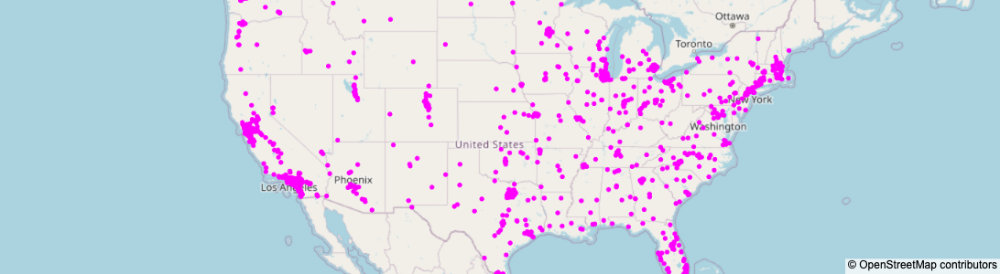

In [1]:
import plotly.express as px
import pandas as pd

us_cities = pd.read_csv(
    "https://raw.githubusercontent.com/plotly/datasets/master/us-cities-top-1k.csv"
)

fig = px.scatter_mapbox(
    us_cities,
    lat="lat",
    lon="lon",
    hover_name="City",
    hover_data=["State", "Population"],
    color_discrete_sequence=["fuchsia"],
    zoom=3,
    height=300,
    width=600,
)
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})
fig.update_layout(mapbox_bounds={"west": -180, "east": -50, "south": 20, "north": 90})
fig.show()

### A local example from Ås

In [2]:
import pandas as pd

# Local restaurants and cafes
restaurants = pd.read_csv('../../data/restaurants.csv')
restaurants

,name,lat,lon,type
0,Sushiko Ås,59.664773,10.789674,Restaurant
1,Charlie's Diner,59.664663,10.788735,Restaurant
2,Jojo's Pizza,59.665496,10.795366,Restaurant
3,Desi Zaiqa,59.664281,10.792276,Restaurant
4,Babylon Pizza,59.663602,10.792977,Restaurant
5,NT kiosk,59.663743,10.793237,Kiosk
6,Aas Bistro,59.663465,10.793558,Restaurant
7,Whytes Coffee,59.664686,10.790830,Café
8,Station kiosk Ås,59.663324,10.794335,Café


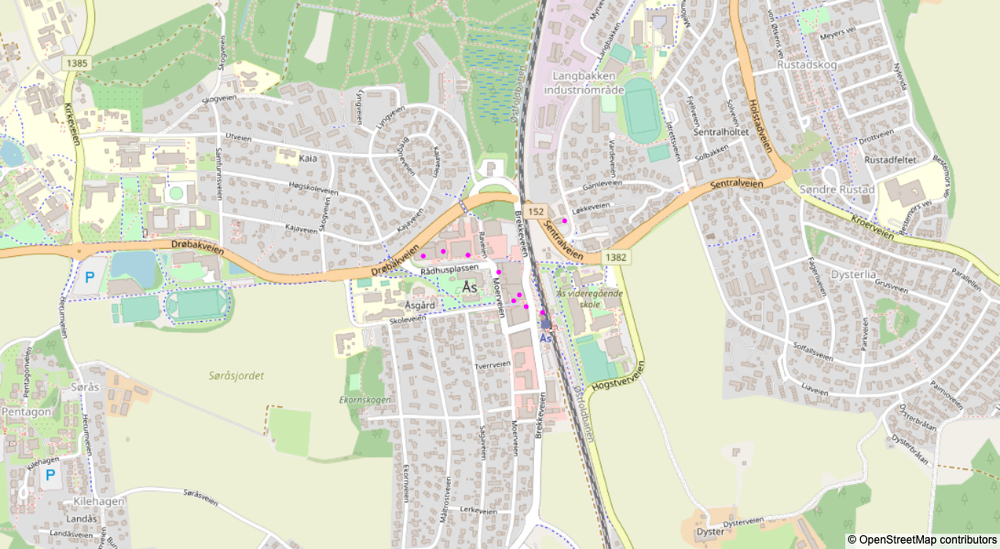

In [3]:
fig_restaurants = px.scatter_mapbox(
    restaurants,
    lat="lat",
    lon="lon",
    hover_name="name",
    hover_data=["type","lat","lon"],
    color_discrete_sequence=["fuchsia"],
    zoom=14,
    height=600,
    width=700,
)
fig_restaurants.update_layout(mapbox_style="open-street-map")
fig_restaurants.update_layout(margin={"r": 0, "t": 0, "l": 0, "b": 0})
#fig_restaurants.update_traces(cluster=dict(enabled=True)) # Group restaurants when zooming out
fig_restaurants.show()

In [4]:
print(fig_restaurants)

Figure({
    'data': [{'customdata': array([['Restaurant', 59.6647728, 10.7896737],
                                   ['Restaurant', 59.6646628, 10.7887347],
                                   ['Restaurant', 59.6654962, 10.7953659],
                                   ['Restaurant', 59.6642813, 10.7922755],
                                   ['Restaurant', 59.6636019, 10.7929767],
                                   ['Kiosk', 59.6637434, 10.7932373],
                                   ['Restaurant', 59.663465, 10.7935577],
                                   ['Café', 59.6646862, 10.7908304],
                                   ['Café', 59.663324, 10.7943351]], dtype=object),
              'hovertemplate': ('<b>%{hovertext}</b><br><br>lat' ... '{customdata[0]}<extra></extra>'),
              'hovertext': array(['Sushiko Ås', "Charlie's Diner", "Jojo's Pizza", 'Desi Zaiqa',
                                  'Babylon Pizza', 'NT kiosk', 'Aas Bistro', 'Whytes Coffee',
                        

### Streamsync integration
- Streamsync has handlers that easily connect interaction with reactive Python code.  

<img src="https://github.com/khliland/IND320/blob/main/D2Dbook/images/streamsync_selection.png?raw=TRUE" width="600px">  

## Choropleths
- A pure choropleth can be plotted using a GeoJSON file, e.g., from https://norgeskart.no/json/norge/.
- In addition a DataFrame containing the map region properties to use for colouring and hover information is needed.

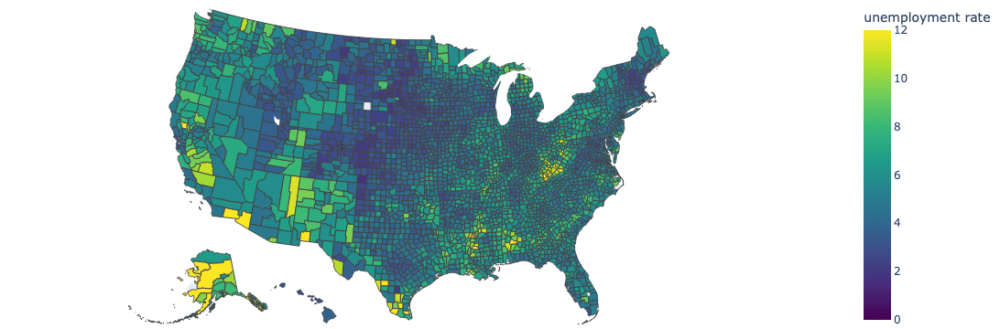

In [5]:
# Choropleth map of US counties with unemployment rate
from urllib.request import urlopen
import json
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)

import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/fips-unemp-16.csv",
                   dtype={"fips": str})

import plotly.express as px

fig = px.choropleth(df, geojson=counties, locations='fips', color='unemp',
                           color_continuous_scale="Viridis",
                           range_color=(0, 12),
                           scope="usa",
                           labels={'unemp':'unemployment rate'}
                          )
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.show()

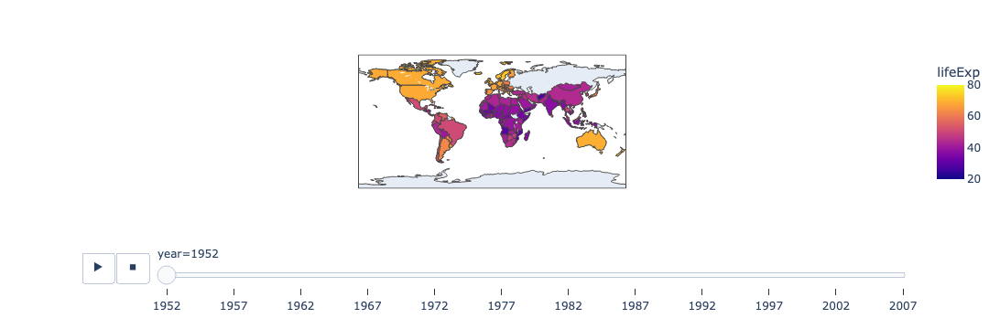

In [6]:
# Gapminder dataset as a map
import plotly.express as px
df = px.data.gapminder()
fig = px.choropleth(df, locations="iso_alpha", color="lifeExp", hover_name="country", animation_frame="year", range_color=[20,80])
fig.show()

```{seealso} Resources
:class: tip
- [Plotly scatter mapbox](https://plotly.com/python/scattermapbox/)
- [Plotly choropleths](https://plotly.com/python/choropleth-maps/)
- [Streamsync demos](https://github.com/jreyesr/streamsync-demos)
```